# Forward-Modeling Simulation Populations

You have a simulation. For each galaxy it gives you a star formation history
and a metallicity history — arrays, not parameters. You want broadband
photometry and emission-line fluxes for all of them, as fast as possible.

That is all this notebook does.

```text
    in :  t [Gyr]        (n_t,)      cosmic time, shared or per galaxy
          SFR(t)         (N, n_t)    Msun/yr
          Z(t)           (N, n_t)    stellar metallicity
    out:  photometry     (N, n_β)    erg/s/cm2/Hz
          line fluxes    (N,)  each  erg/s/cm2
          properties     (N,)  each  stellar mass, SFR, ...
```

There is no fitting here and **no free parameters** — the tables are the
model. Sections 1–3 are the working code; sections 4–5 are the speed, which
is the part worth reading twice.

For scale: on the laptop CPU this was written on, the configuration in
section 1 runs **~8,000 galaxies per second** — 4096 histories through 11
bands in about half a second, on a CPU, with no GPU involved. Section 5
measures each lever that gets you there separately, because they do **not**
simply multiply: whichever term currently dominates is the only one worth
optimizing next.

In [1]:
from _setup import FIG_DIR, quiet

quiet()

import time

import matplotlib.pyplot as plt
import numpy as np

import jax

import tengri
from tengri import (
    FIXED,
    Catalog,
    Fixed,
    ForwardModel,
    Observation,
    Photometry,
    SEDModel,
    WavePrecomp,
    plot,
)
from tengri.utils.cosmology import age_at_z

plot.setup_style()
print(f"JAX backend: {jax.devices()[0].platform}   x64: {jax.config.jax_enable_x64}")

JAX backend: cpu   x64: True


## 1. The model

Four choices, and three of them are the speed. Each line below is annotated
with why it is there; section 5 measures what each one costs if you choose
otherwise.

In [2]:
Z_OBS = 0.1  # snapshot redshift
T_OBS = float(age_at_z(Z_OBS))  # age of the universe there [Gyr]

# wNE = "with nebular emission": lines and nebular continuum are baked into the
# SSP templates. This is the fast configuration AND the one that gives you
# emission lines — see section 3.
ssp = tengri.load_ssp("prsc_miles_chabrier_wNE", download=True)

BANDS = [f"sdss_{b}" for b in "ugriz"] + [f"lsst_{b}" for b in "ugrizy"]
phot = Photometry.from_names(BANDS)


PRECOMP = WavePrecomp()  # the SSP x filter lookup table; see section 5b


def build_model(approx=PRECOMP, neb=None):
    """The forward operator. Defaults are the fast configuration.

    Pass ``approx=None`` for the exact wavelength-grid path (section 5b).
    """
    sed = SEDModel.build(
        ssp_data=ssp,
        observation=Observation(photometry=phot),
        redshift=Fixed(Z_OBS),
        sfh={"type": "table"},  # SFH arrives at runtime, as data
        met={"type": "table"},  # so does the stellar metallicity
        dust={"type": "two_component", "law_bc": "calzetti", "*": FIXED},
        neb=neb or {"type": "ssp"},  # baked into the SSP: zero per-galaxy cost
        approx=approx,  # SSP x filter LUT, or None for the exact path
    )
    return ForwardModel.build(sed=sed)


fwd = build_model()
print(f"{phot.n_filters} bands   free parameters: {fwd.spec.free_params}")

/Users/suchethacooray/Projects/tengri/.claude/worktrees/met-histories/src/tengri/components/stellar/sps/dsps_wrapper.py:298: UserWarning: 'ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5' is a wNE (with-Nebular-Emission) SSP: nebular continuum and lines are already baked into the templates at fixed logU/logZ_gas. Pair it with the default baked-in nebular backend only — adding neb={'type': 'cue'} or a CLOUDY grid on top double-counts nebular emission.
  return load_ssp_data(str(candidate))


11 bands   free parameters: []


## 2. The histories

Substitute your snapshot reader here. This stand-in produces the same thing:
a time grid, `SFR(t)`, and `Z(t)` as a **metal mass fraction**.

**The one unit trap.** `met_unit=` is required reading, not a formality.
tengri's internal convention is log10(Z/Zsun); a snapshot stores raw *Z*.
`Z = 2e-4` is a legal value in *both*, so a mass fraction silently read as
log10(Z/Zsun) is a factor of ~70 error that no range check can catch. Declare
it: `"z_mass_fraction"`, `"logzsol"`, or `"log_z_abs"`.

In [3]:
N_T = 96


def simulation_snapshot(n_galaxies, seed=11):
    """Stand-in for a snapshot reader: t [Gyr], SFR [Msun/yr], Z (mass fraction)."""
    rng = np.random.default_rng(seed)
    log_mass = rng.uniform(8.5, 11.5, n_galaxies)
    quenched = rng.random(n_galaxies) < 1.0 / (1.0 + np.exp(-(log_mass - 10.4) / 0.35))
    t_form = np.where(
        quenched, rng.uniform(0.3, 1.5, n_galaxies), rng.uniform(1.0, 4.0, n_galaxies)
    )
    tau = np.where(
        quenched,
        10 ** rng.uniform(-0.30, 0.15, n_galaxies),
        10 ** rng.uniform(0.45, 0.95, n_galaxies),
    )

    t_gyr = np.linspace(0.05, T_OBS, N_T)
    since = np.clip(t_gyr[None, :] - t_form[:, None], 0.0, None)
    sfr = (since / tau[:, None]) * np.exp(-since / tau[:, None])
    dt_yr = np.gradient(t_gyr) * 1e9
    sfr *= (10**log_mass / (sfr * dt_yr[None, :]).sum(axis=1))[:, None]

    # Closed-box enrichment: Z rises as the gas is converted into stars.
    mass_formed = np.cumsum(sfr * dt_yr[None, :], axis=1)
    efficiency = np.interp(log_mass, [8.5, 11.5], [0.15, 0.75])
    met = 0.02 * np.log(1.0 / (1.0 - mass_formed / (10**log_mass / efficiency)[:, None]))
    return dict(t_gyr=t_gyr, sfr=sfr, met=met, log_mass=log_mass, quenched=quenched)


snap = simulation_snapshot(500)

# The SSP grid has a lowest metallicity node; simulations go below it at early
# times. Off-grid values are CLIPPED inside JIT where nothing can raise, so
# ingest refuses them by default rather than returning a plausible wrong SED.
# Clip deliberately (here, at the grid's own edge) or pass on_out_of_grid='warn'.
Z_FLOOR = 10 ** np.asarray(ssp.ssp_lgmet).min()
met = np.maximum(snap["met"], Z_FLOOR)
print(
    f"SFR {snap['sfr'].shape}   Z {met.shape}   floor Z={Z_FLOOR:.1e} "
    f"raised {(snap['met'] < Z_FLOOR).mean():.0%} of nodes"
)

SFR (500, 96)   Z (500, 96)   floor Z=1.0e-04 raised 19% of nodes


## 3. Predict photometry and lines

`Catalog.from_histories` validates eagerly (before any compile), then
`simulate` runs the whole population as one vectorized program.

**Where lines come from matters.** With baked-in nebular there are two
channels and only one of them works:

| you want | ask for | with `neb={'type':'ssp'}` |
|---|---|---|
| *measured* line flux, continuum-subtracted like an observation | `lines=(...)` | works, fast |
| *intrinsic* line luminosity from a photoionization model | `properties=("halpha",…)` | returns **NaN** |

The intrinsic route needs a live backend (`neb={'type':'cue'}` or
`{'type':'cloudy'}`), which also lets you set the gas-phase metallicity
separately via `met_gas=`. Section 5 measures what that costs.

In [4]:
LINES = ("Halpha", "Hbeta", "OIII_5007", "NII_6584", "SII_6717")
PROPS = ("stellar_mass", "sfr_100myr", "ssfr", "mass_weighted_metallicity")

cat = Catalog.from_histories(
    fwd,
    t_gyr=snap["t_gyr"],  # (n_t,)   shared grid, broadcast
    sfr=snap["sfr"],  # (N, n_t)
    met=met,  # (N, n_t) stellar metallicity history
    met_unit="z_mass_fraction",  # declared, never guessed
)

mock = cat.simulate(lines=LINES, properties=PROPS, chunk_size=128)

flux = mock.photometry  # (N, n_bands) erg/s/cm2/Hz
props = {k: np.asarray(v) for k, v in mock.properties.items()}
lines = {k: np.asarray(v) for k, v in mock.lines.items()}

print(f"photometry {flux.shape}   lines {list(lines)}   properties {list(props)}")
print(
    f"log M* in  {snap['log_mass'].min():.2f}..{snap['log_mass'].max():.2f}   "
    f"out {np.log10(props['stellar_mass']).min():.2f}.."
    f"{np.log10(props['stellar_mass']).max():.2f}"
)
print(
    f"max |log M* recovered - input| = "
    f"{np.abs(np.log10(props['stellar_mass']) - snap['log_mass']).max():.1e} dex"
)

photometry (500, 11)   lines ['Halpha', 'Hbeta', 'OIII_5007', 'NII_6584', 'SII_6717']   properties ['mass_weighted_metallicity', 'sfr_100myr', 'ssfr', 'stellar_mass']
log M* in  8.51..11.50   out 8.50..11.50
max |log M* recovered - input| = 4.6e-03 dex


The mass round-trips to a few thousandths of a dex — two different quadratures
of the same table, not a disagreement about what the table says.

The sanity check worth doing on any mock: emission lines must track the recent
star formation that powers them.

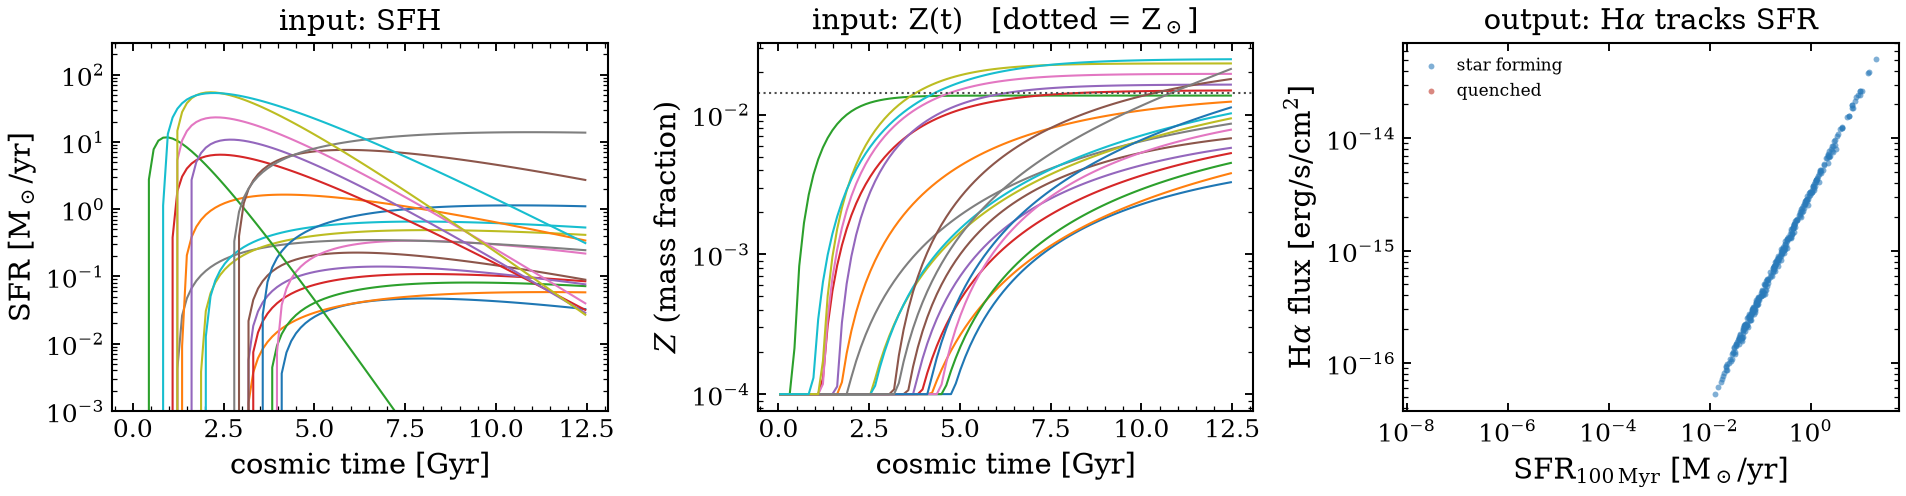

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
q = snap["quenched"]
sf = ~q

axes[0].plot(snap["t_gyr"], snap["sfr"][np.argsort(snap["log_mass"])[::25]].T, lw=1)
axes[0].set(
    xlabel="cosmic time [Gyr]",
    ylabel=r"SFR [M$_\odot$/yr]",
    yscale="log",
    ylim=(1e-3, 3e2),
    title="input: SFH",
)

axes[1].plot(snap["t_gyr"], met[np.argsort(snap["log_mass"])[::25]].T, lw=1)
axes[1].axhline(0.0142, color="0.3", ls=":", lw=1)
axes[1].set(
    xlabel="cosmic time [Gyr]",
    ylabel="$Z$ (mass fraction)",
    yscale="log",
    title=r"input: Z(t)   [dotted = Z$_\odot$]",
)

axes[2].scatter(
    props["sfr_100myr"][sf],
    lines["Halpha"][sf],
    s=8,
    alpha=0.6,
    lw=0,
    c="#2b7bba",
    label="star forming",
)
axes[2].scatter(
    props["sfr_100myr"][q], lines["Halpha"][q], s=8, alpha=0.6, lw=0, c="#c0392b", label="quenched"
)
axes[2].set(
    xscale="log",
    yscale="log",
    xlabel=r"SFR$_{100\,\rm Myr}$ [M$_\odot$/yr]",
    ylabel=r"H$\alpha$ flux [erg/s/cm$^2$]",
    title=r"output: H$\alpha$ tracks SFR",
)
axes[2].legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "12_in_out.png", dpi=140)
plt.show()

## 4. Vectorizing it yourself

`Catalog` is convenient, but if you are wiring this into your own pipeline you
want the `vmap` directly. The whole trick is that **the parameter dict is a
pytree, and `vmap` maps the leading axis of every leaf**:

```python
{"sfh_t_gyr": (N, n_t),      # a history
 "sfh_sfr":   (N, n_t),      # a history
 "met_history": (N, n_t),    # a history
 "dust_tau_diff": (N,)}      # a per-galaxy scalar
```

Nothing has to agree beyond that leading galaxy axis — scalars and histories
batch through the same call. Here are the columns `Catalog` builds, which is
exactly what you would assemble by hand:

In [6]:
columns = {k: np.asarray(v) for k, v in cat._history_columns.items()}
for k, v in columns.items():
    print(f"   {k:16s} {v.shape}")

one = {k: v[0] for k, v in columns.items()}  # a single galaxy
batch = {k: v[:256] for k, v in columns.items()}  # 256 of them
K = 256

   sfh_t_gyr        (500, 96)
   sfh_sfr          (500, 96)
   met_history      (500, 96)


Four ways to run it. The timings use `block_until_ready` — JAX dispatch is
asynchronous, and without it you are timing the queue, not the work.

In [7]:


def bench(fn, arg, n, reps=5):
    jax.block_until_ready(fn(arg))  # warm: compile happens here
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(arg))
        ts.append(time.perf_counter() - t0)
    return min(ts) / n


# (a) one galaxy at a time
f_one = jax.jit(fwd.predict_photometry)
t_one = bench(f_one, one, 1, reps=20)

# (b) vmap alone -- vectorized, but NOT compiled as one program
f_vmap = jax.vmap(fwd.predict_photometry)
t_vmap = bench(f_vmap, batch, K, reps=3)

# (c) jit(vmap(...)) -- this is the one you want
f_jitvmap = jax.jit(jax.vmap(fwd.predict_photometry))
t_jitvmap = bench(f_jitvmap, batch, K, reps=5)

# (d) Catalog: (c) plus chunking, padding, and a cross-call compile cache
cat_k = Catalog.from_histories(
    fwd, t_gyr=snap["t_gyr"], sfr=snap["sfr"][:K], met=met[:K], met_unit="z_mass_fraction"
)
cat_k.predict(chunk_size=K)
t0 = time.perf_counter()
cat_k.predict(chunk_size=K)
t_cat = (time.perf_counter() - t0) / K

print(f"{'':34s}{'ms/galaxy':>11s}{'galaxies/s':>13s}")
for label, t in (
    ("(a) jit, one galaxy", t_one),
    ("(b) vmap without jit", t_vmap),
    ("(c) jit(vmap(...))", t_jitvmap),
    ("(d) Catalog.predict", t_cat),
):
    print(f"  {label:32s}{1e3 * t:10.3f}{1 / t:13.0f}")
print(f"\n  (a) -> (c)  vectorizing wins {t_one / t_jitvmap:.1f}x")
print(f"  (b) -> (c)  jit-ing the vmap wins {t_vmap / t_jitvmap:.1f}x")

                                    ms/galaxy   galaxies/s
  (a) jit, one galaxy                  0.284         3517
  (b) vmap without jit                 0.124         8096
  (c) jit(vmap(...))                   0.106         9430
  (d) Catalog.predict                  0.116         8588

  (a) -> (c)  vectorizing wins 2.7x
  (b) -> (c)  jit-ing the vmap wins 1.2x


Two things to take from that table.

**`vmap` without `jit` is leaving money on the table.** Bare `vmap` dispatches
op by op, so each primitive is compiled and launched separately. The steady
state is only somewhat slower, but the *first* call is several times worse
because it compiles many small programs instead of one big one. Always
`jit(vmap(f))`, never bare `vmap(f)`.

**Every distinct batch width is its own compile.** JAX keys its cache on
shape, so a ragged trailing chunk — 128, 128, 47 — compiles the program
twice. Pad to a uniform width:

In [8]:
for width in (100, 99):
    sub = {k: v[:width] for k, v in columns.items()}
    t0 = time.perf_counter()
    jax.block_until_ready(f_jitvmap(sub))
    print(f"   first call at width {width:4d}: {time.perf_counter() - t0:5.2f} s  (a compile)")
print("\n   -> two widths, two compiles. Catalog.predict pads for you; if you")
print("      roll your own, pad the last chunk and discard the extra rows.")

   first call at width  100:  0.18 s  (a compile)


   first call at width   99:  0.18 s  (a compile)

   -> two widths, two compiles. Catalog.predict pads for you; if you
      roll your own, pad the last chunk and discard the extra rows.


## 5. The optimization ladder

Measured on this machine, on the backend printed at the top. Re-run rather
than quoting these numbers.

### 5a. The nebular backend is the biggest single lever

In [9]:
bench_snap = simulation_snapshot(256, seed=5)
bench_met = np.maximum(bench_snap["met"], Z_FLOOR)


def throughput(model, n=256, chunk=128, reps=3, gas=False):
    """Warm ms/galaxy for a whole catalog through `model`.

    ``gas=True`` also supplies the gas-phase metallicity, which a live nebular
    backend accepts (and warns about if omitted) and a baked-in one refuses.
    """
    c = Catalog.from_histories(
        model,
        t_gyr=bench_snap["t_gyr"],
        sfr=bench_snap["sfr"][:n],
        met=bench_met[:n],
        met_gas=bench_met[:n, -1] if gas else None,
        met_unit="z_mass_fraction",
    )
    c.predict(chunk_size=chunk)
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter()
        c.predict(chunk_size=chunk)
        ts.append(time.perf_counter() - t0)
    return min(ts) / n


ssp_bare = tengri.load_ssp(download=True)  # bare-stellar, required by Cloudy


def build_cloudy():
    sed = SEDModel.build(
        ssp_data=ssp_bare,
        observation=Observation(photometry=phot),
        redshift=Fixed(Z_OBS),
        sfh={"type": "table"},
        met={"type": "table"},
        dust={"type": "two_component", "law_bc": "calzetti", "*": FIXED},
        neb={"type": "cloudy"},
        approx=WavePrecomp(),
    )
    return ForwardModel.build(sed=sed)


t_baked = throughput(fwd)
t_cloudy = throughput(build_cloudy(), gas=True)
print(f"  neb='ssp'    (baked into the SSP) {1e3 * t_baked:7.3f} ms/gal {1 / t_baked:9.0f} gal/s")
print(
    f"  neb='cloudy' (live photoionization){1e3 * t_cloudy:6.3f} ms/gal {1 / t_cloudy:9.0f} gal/s"
)
print(f"\n  baked-in is {t_cloudy / t_baked:.0f}x faster.")

/Users/suchethacooray/Projects/tengri/.claude/worktrees/met-histories/src/tengri/forward/sed_model.py:2503: CloudyGridIonizingSpectrumWarning: CloudyGridBackend: Q_H is computed from your DSPS SSPs (correct for stellar mass accounting), but the ionizing spectral shape used to compute the CLOUDY grid was BPASS v2.1 binary stars. If your SSPs have a significantly harder/softer ionizing SED than BPASS (e.g., single-star models, stripped-star prescriptions, very young/old populations), predicted line ratios will be biased. Use CueBackend if ionizing SED shape variation matters for your science. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = CloudyGridBackend(spec.cloudy_grid_path, ssp_data)


  neb='ssp'    (baked into the SSP)   0.118 ms/gal      8453 gal/s
  neb='cloudy' (live photoionization) 4.193 ms/gal       238 gal/s

  baked-in is 35x faster.


That is the choice to make first, and it is a physics choice, not a tuning
knob. Baked-in fixes the ionization parameter and escape fraction at
grid-build time and gives you no `met_gas=`; a live backend lets the
gas-phase metallicity be a separate per-galaxy input and gives you intrinsic
line luminosities. If you only need broadband colors and measured line
fluxes, baked-in is the right answer *and* the fast one.

### 5b. `WavePrecomp`

The exact path integrates the SSP x filter product on the full wavelength
grid on every call. `WavePrecomp` tabulates that once at build time and
interpolates. It costs a slower build and repays it on every evaluation.

In [10]:
t_exact = throughput(build_model(approx=None))
print(f"  approx=None          (exact grid) {1e3 * t_exact:7.3f} ms/gal {1 / t_exact:9.0f} gal/s")
print(
    f"  approx=WavePrecomp() (SSP x filter LUT) {1e3 * t_baked:6.3f} ms/gal "
    f"{1 / t_baked:9.0f} gal/s"
)
print(f"\n  WavePrecomp is {t_exact / t_baked:.1f}x faster.")

  approx=None          (exact grid)   5.461 ms/gal       183 gal/s
  approx=WavePrecomp() (SSP x filter LUT)  0.118 ms/gal      8453 gal/s

  WavePrecomp is 46.2x faster.


Note how the two levers interact. On the baked-in configuration `WavePrecomp`
is worth a large factor, because the SSP x filter integral is then most of the
remaining work. Put a live nebular emulator back in and the same `WavePrecomp`
is worth only about 2x — not because it got worse, but because the emulator
now dominates. **Optimize the biggest term first**, and re-measure after each
change rather than assuming the factors multiply.

### 5c. Batch width and scaling

In [11]:
print(f"{'chunk_size':>11s}{'ms/galaxy':>12s}{'galaxies/s':>13s}")
for chunk in (32, 64, 128, 256):
    t = throughput(fwd, n=256, chunk=chunk)
    print(f"{chunk:11d}{1e3 * t:11.3f}{1 / t:13.0f}")

print()
print(f"{'N':>8s}{'wall':>9s}{'ms/galaxy':>12s}{'galaxies/s':>13s}")
for n in (256, 1024, 4096):
    s = simulation_snapshot(n, seed=17)
    c = Catalog.from_histories(
        fwd,
        t_gyr=s["t_gyr"],
        sfr=s["sfr"],
        met=np.maximum(s["met"], Z_FLOOR),
        met_unit="z_mass_fraction",
    )
    c.predict(chunk_size=128)
    t0 = time.perf_counter()
    c.predict(chunk_size=128)
    dt = time.perf_counter() - t0
    print(f"{n:8d}{dt:8.2f}s{1e3 * dt / n:11.3f}{n / dt:13.0f}")

 chunk_size   ms/galaxy   galaxies/s


         32      0.186         5390


         64      0.151         6642


        128      0.132         7567


        256      0.122         8192

       N     wall   ms/galaxy   galaxies/s


     256    0.04s      0.138         7223


    1024    0.13s      0.130         7690


    4096    0.57s      0.139         7205


Per-galaxy cost is flat in *N* to within measurement scatter, so a bigger
catalog is just proportionally more wall clock. `chunk_size` trades memory for
throughput **linearly** — each vmapped galaxy carries its own SFH and Z(t)
through the SSP machinery, and the default of 1024 was enough to exhaust
memory on the laptop this was written on. If a run dies with no Python
traceback, turn it down first.

## The whole thing

```python
import numpy as np, tengri
from tengri import (Catalog, Fixed, FIXED, ForwardModel, Observation,
                    Photometry, SEDModel, WavePrecomp)

ssp = tengri.load_ssp("prsc_miles_chabrier_wNE", download=True)
obs = Observation(photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r"]))

fwd = ForwardModel.build(sed=SEDModel.build(
    ssp_data=ssp, observation=obs, redshift=Fixed(0.1),
    sfh={"type": "table"}, met={"type": "table"},
    dust={"type": "two_component", "law_bc": "calzetti", "*": FIXED},
    neb={"type": "ssp"}, approx=WavePrecomp(),
))

cat = Catalog.from_histories(fwd, t_gyr=t, sfr=sfr, met=Z,
                             met_unit="z_mass_fraction")
mock = cat.simulate(lines=("Halpha", "OIII_5007"),
                    properties=("stellar_mass", "sfr_100myr"), chunk_size=128)
mock.photometry            # (N, n_bands)  erg/s/cm2/Hz
mock.lines["Halpha"]       # (N,)          erg/s/cm2
mock.to_table()
```

Per-galaxy scalars ride along with `params={"dust_tau_diff": tau}`; per-galaxy
redshifts need `redshift=` plus a `WavePrecomp(catalog_z_range=(zmin, zmax))`
so the program still compiles once.